# Project Stochastic Simulation SRN

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Section 3.2


In [33]:
c = [0.0017, 1e-4, 0.1]  # rate constants
T = 50  # Total time
X0 = np.array([312, 125, 0, 0])

In [34]:
nu = np.array([[-1, -1, 1, 0], [1, 1, -1, 0], [0, 1, -1, 1]])  # stochiometric vectors


def aCalc(x, c):
    a1 = c[0] * (x[0] * x[1]) * (x[0] >= 1 and x[1] >= 1)
    a2 = c[1] * (x[2]) * (x[2] >= 1)
    a3 = c[2] * (x[2]) * (x[2] >= 1)
    return np.array([a1, a2, a3])

### 3.2.1  - more exact equations for each single species in the report - in the report

Here are the functions to compute the drift vector f(x) and the diffusion matrix G(x) for the CLE.

In [37]:
def simple_cle_drift(x, c):
    a = aCalc(x, c)

    f1 = -a[0] + a[1]
    f2 = -a[0] + a[1] + a[2]
    f3 = a[0] - a[1] - a[2]
    f4 = a[2]

    return np.array([f1, f2, f3, f4])


def cle_drift(x, c):
    """Return the drift vector f(x) = sum_j nu_j * a_j(x). - optimized with matrix multiplication
    Returns a numpy array of length 4.
    """
    a = aCalc(x, c)
    return a @ nu


def simple_cle_diffusion(x, c):
    a = aCalc(x, c)

    sqrt_a1 = math.sqrt(a[0])
    sqrt_a2 = math.sqrt(a[1])
    sqrt_a3 = math.sqrt(a[2])

    H = np.zeros((4, 3))

   # --- Column 0: Reaction 1 Noise (affects S1, S2, S3) ---
    H[0, 0] = -1 * sqrt_a1  # S1
    H[1, 0] = -1 * sqrt_a1  # S2
    H[2, 0] =  1 * sqrt_a1  # S3

    # --- Column 1: Reaction 2 Noise (affects S1, S2, S3) ---
    H[0, 1] =  1 * sqrt_a2  # S1
    H[1, 1] =  1 * sqrt_a2  # S2
    H[2, 1] = -1 * sqrt_a2  # S3

    # --- Column 2: Reaction 3 Noise (affects S2, S3, S4) ---
    H[1, 2] =  1 * sqrt_a3  # S2
    H[2, 2] = -1 * sqrt_a3  # S3
    H[3, 2] =  1 * sqrt_a3  # S4

    return H

def cle_diffusion(x, c):
    """Return the diffusion matrix G(x) with shape (4,3).
    Column j is nu[j] * sqrt(a_j(x)).
    """
    a = aCalc(x, c)
    J = a.shape[0]
    H = np.zeros((nu.shape[1], J))

    for j in range(J):
        H[:, j] = nu[j] * math.sqrt(a[j])
    return G



### 3.2.2 Euler–Maruyama simulation of the CLE (tau = 0.2)

We simulate the CLE using the Euler–Maruyama scheme with time step tau = 0.2, starting from the same initial condition as before. The numerical update is:

    Y_{n+1} = Y_n + tau * f(Y_n) + sqrt(tau) * G(Y_n) Z_n

where Z_n ~ N(0, I) (one normal per reaction). We take the absolute value after each step to avoid negative molecule counts in the visualization.


In [43]:
tau = 0.2
n_steps = int(np.ceil(T / tau))
times = np.linspace(0, T, n_steps + 1)

n_ens = 50
rng = np.random.default_rng(42)
trajs = np.zeros((n_ens, n_steps + 1, X0.size))

for s in range(n_ens):
    x = X0.astype(float).copy()
    trajs[s, 0, :] = x
    for n in range(n_steps):
        #f = simple_cle_drift(x)
        f = cle_drift(x, c)
        #G = simple_cle_diffusion(x)
        G = cle_diffusion(x, c)
        z = rng.normal(size=(G.shape[1],))
        x = x + tau * f + math.sqrt(tau) * (G @ z)
        x = np.abs(x) # note from the report - take absolute value to avoid negative molecule counts
        trajs[s, n + 1, :] = x

# Compute mean and 95% confidence intervals
mean = trajs.mean(axis=0)
sem = trajs.std(axis=0, ddof=1) / math.sqrt(n_ens)
ci_low = mean - 1.96 * sem  # 1.96 for 95% CI - from standard table - maybe needs to be reworked
ci_high = mean + 1.96 * sem

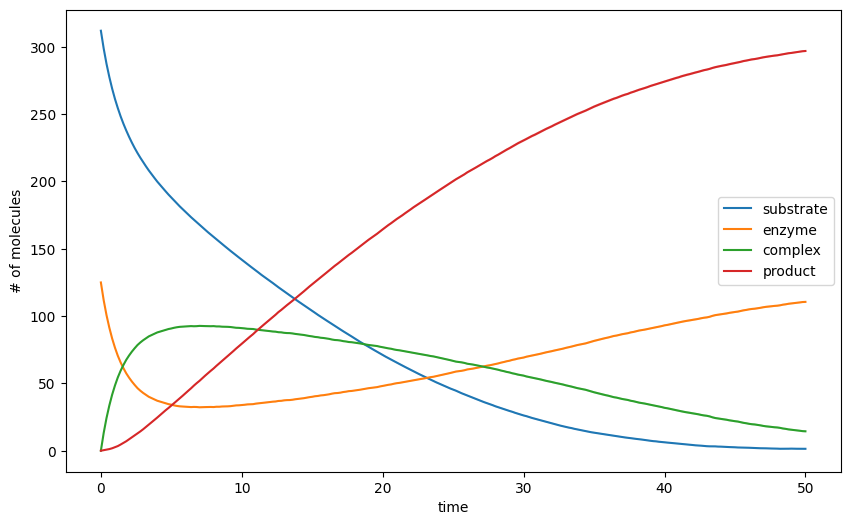

In [42]:

plt.figure(figsize=(10, 6))
labels = ['substrate', 'enzyme', 'complex', 'product']
for i in range(X0.size):
    plt.plot(times, mean[:, i], label=labels[i])
    plt.fill_between(times, ci_low[:, i], ci_high[:, i], alpha=0.2)
plt.xlabel("time")
plt.ylabel("# of molecules")
plt.legend()
plt.show()


### 3.2.3 Comparison with Tau-leaping and SSA (minimal)

We compare CLE, tau-leaping and SSA with a fixed computational budget.
